In [266]:
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [267]:
data=pd.read_csv("a1_loan_approval_data.csv")

In [234]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Handling missing values

In [268]:
categorical_cols=data.select_dtypes(include=["object"]).columns
numerical_cols=data.select_dtypes(include=["float64"]).columns

In [269]:
num_imp=SimpleImputer(strategy="mean")
data[numerical_cols]=num_imp.fit_transform(data[numerical_cols])

cat_imp=SimpleImputer(strategy="most_frequent")
data[categorical_cols]=cat_imp.fit_transform(data[categorical_cols])


In [270]:
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

EDA

Text(0.5, 1.0, 'Is loan approved')

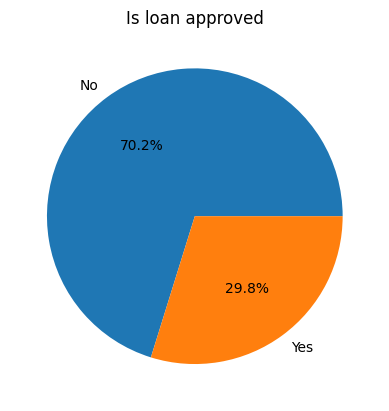

In [186]:
#how balanced our data is
classes_count=data["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is loan approved")

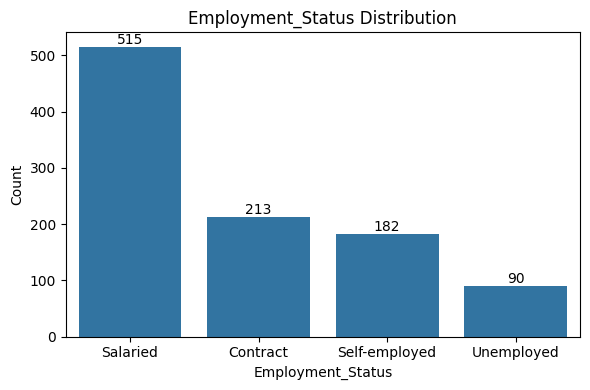

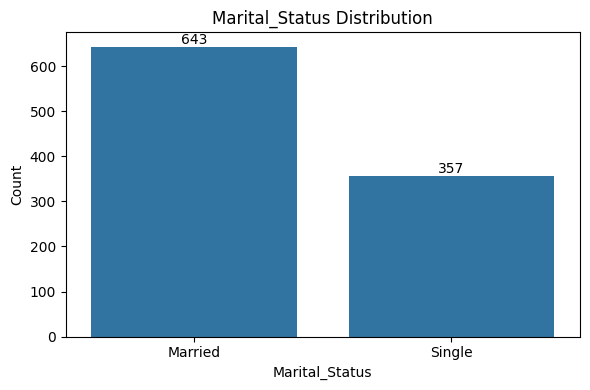

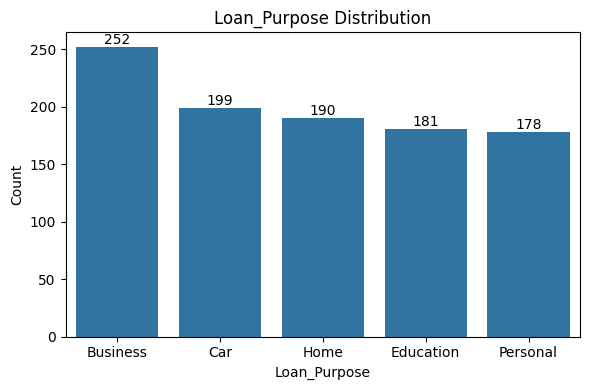

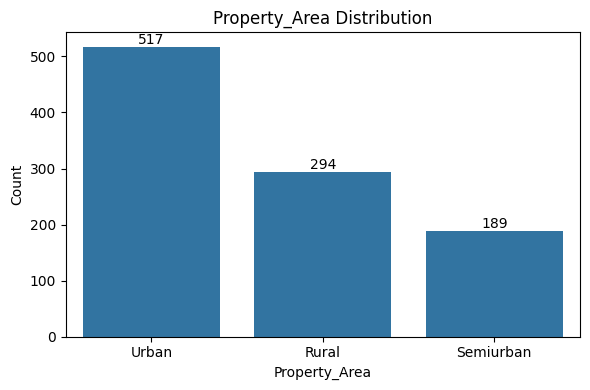

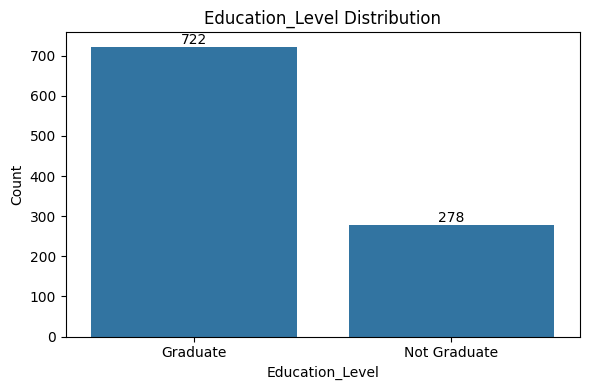

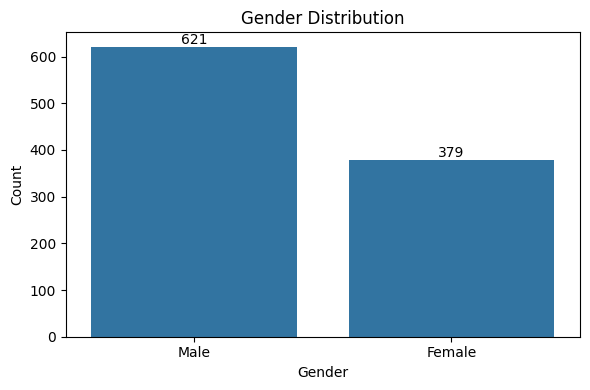

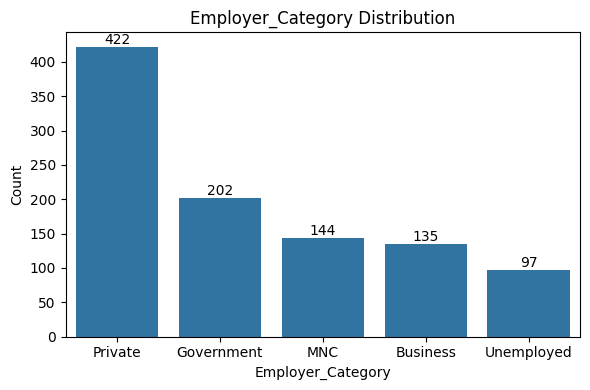

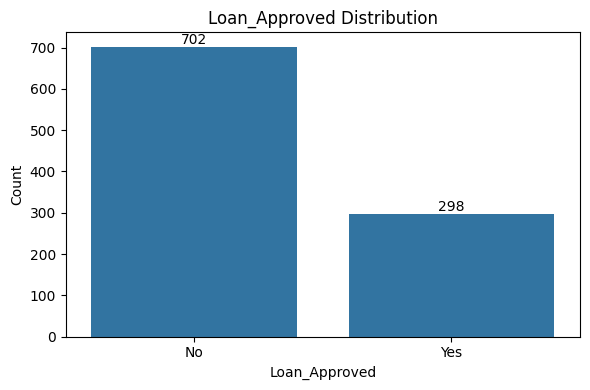

In [187]:
#analyze categories

for i in  range(len(categorical_cols)):
    plt.figure(figsize=(6,4))    
    cnt=data[categorical_cols[i]].value_counts()
    ax=sns.barplot(x=cnt.index,
                  y=cnt.values)
    ax.bar_label(ax.containers[0])
    ax.set_title(f"{categorical_cols[i]} Distribution")
    ax.set_xlabel(categorical_cols[i])
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
    


<Axes: xlabel='Applicant_Income', ylabel='Count'>

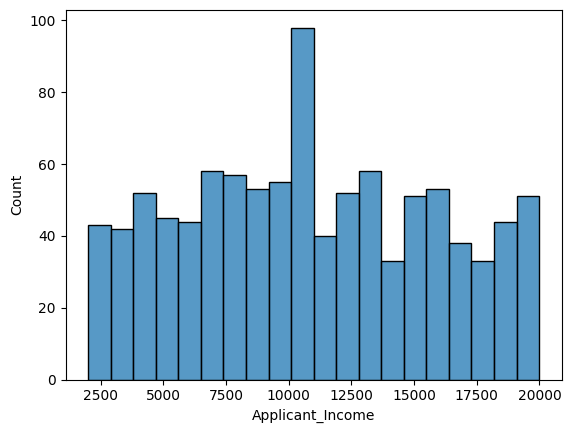

In [188]:
sns.histplot(
    data=data,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

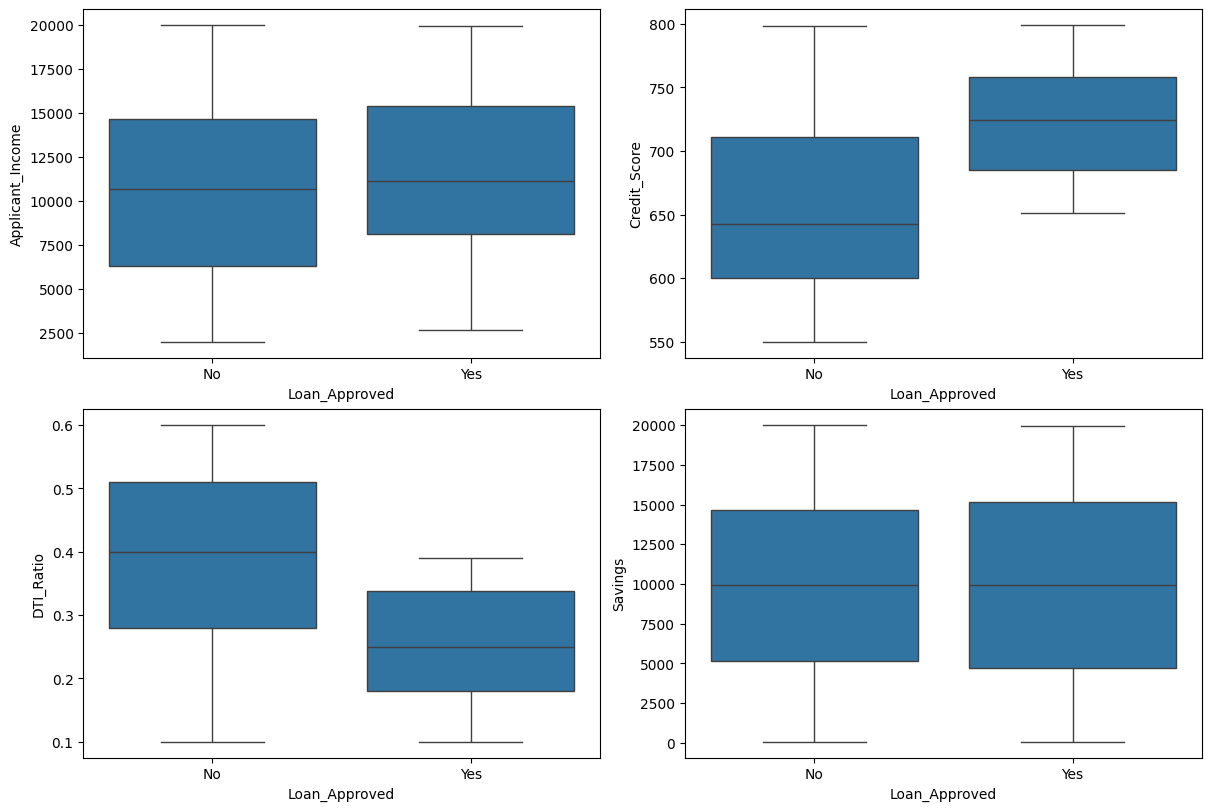

In [189]:
fig,axes=plt.subplots(2,2, figsize=(12, 8), constrained_layout=True)

sns.boxplot(ax=axes[0,0],data=data,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=data,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=data,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=data,x="Loan_Approved",y="Savings")


Encoding

In [271]:
data=data.drop("Applicant_ID",axis=1)

In [272]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
data["Education_Level"]=le.fit_transform(data["Education_Level"])
data["Loan_Approved"]=le.fit_transform(data["Loan_Approved"])


In [273]:
cols=["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe=OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore")

encoded=ohe.fit_transform(data[cols])

encoded_data=pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=data.index)

data=pd.concat(
    [data.drop(columns=cols),
     encoded_data],
     axis=1)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [274]:
num_cols=data.select_dtypes(include="number")
corr_matrix=num_cols.corr()
print(corr_matrix)

                                 Applicant_Income  Coapplicant_Income  \
Applicant_Income                         1.000000            0.007545   
Coapplicant_Income                       0.007545            1.000000   
Age                                     -0.023988            0.014306   
Dependents                              -0.026658           -0.026733   
Credit_Score                            -0.009818            0.058423   
Existing_Loans                          -0.010457            0.012418   
DTI_Ratio                               -0.009107            0.058078   
Savings                                 -0.028358           -0.015047   
Collateral_Value                         0.018789            0.009457   
Loan_Amount                             -0.024143            0.001596   
Loan_Term                               -0.033258            0.005894   
Education_Level                         -0.014593           -0.022918   
Loan_Approved                            0.119796  

In [244]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.404817
Applicant_Income                   0.099770
Employer_Category_MNC              0.062015
Marital_Status_Single              0.053416
Collateral_Value                   0.040321
Employment_Status_nan              0.040155
Loan_Purpose_nan                   0.040155
Employer_Category_Private          0.035304
Gender_nan                         0.032282
Loan_Purpose_Personal              0.027617
Coapplicant_Income                 0.026428
Dependents                         0.022332
Loan_Purpose_Education             0.013201
Property_Area_Urban                0.010779
Property_Area_nan                  0.008661
Loan_Purpose_Home                  0.006036
Employment_Status_Self-employed   -0.001939
Marital_Status_nan                -0.007086
Property_Area_Semiurban           -0.014122
Education_Level                   -0.019102
Gender_Male                       -0.021697
Employer_Category_Government    

<Axes: >

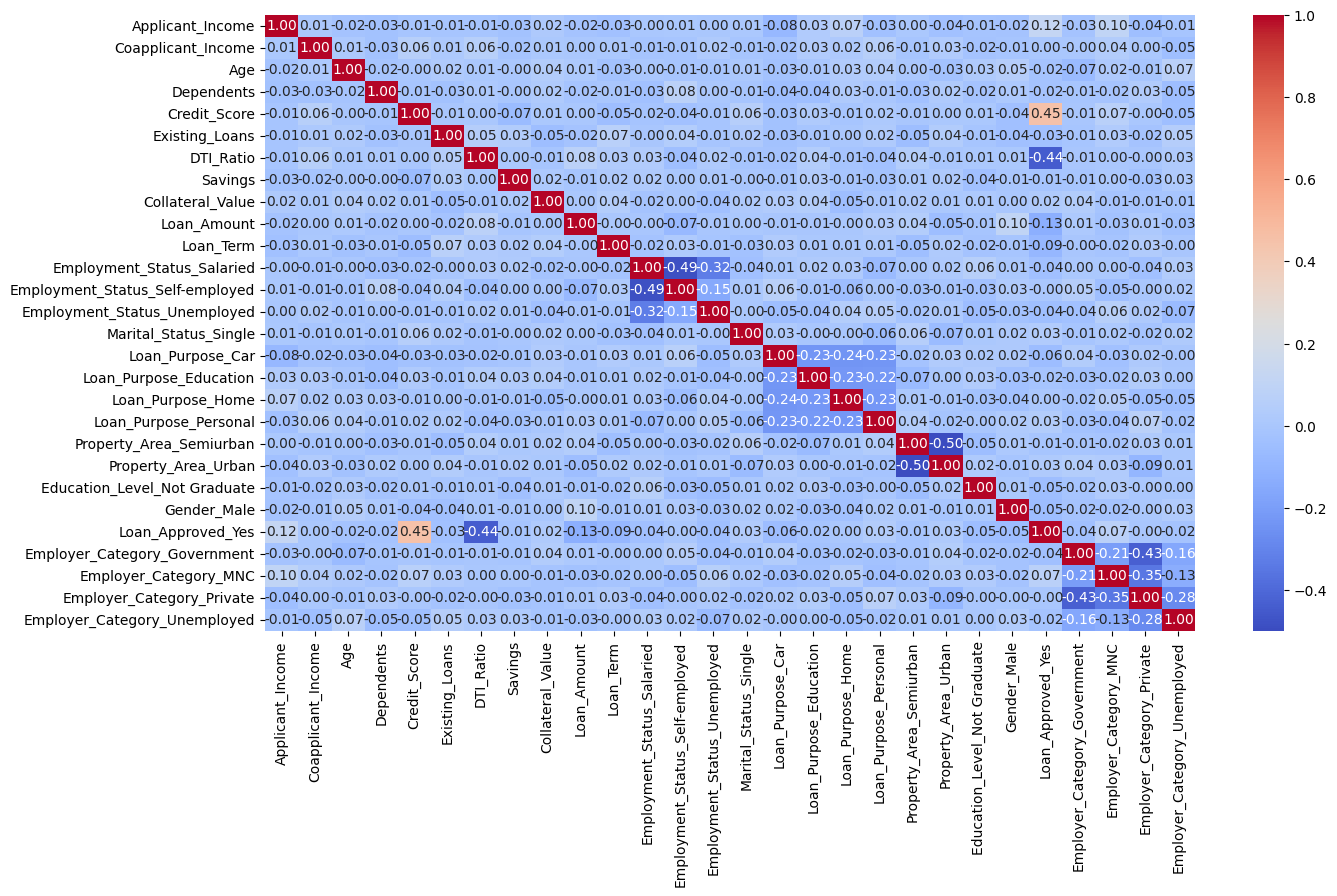

In [275]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

Train-Test split+feature scaling

In [276]:
from sklearn.model_selection import train_test_split


In [277]:
x=data.drop("Loan_Approved",axis=1)
y=data["Loan_Approved"]

In [278]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [279]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [283]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("Logistic Regression Model")
print("precision_score",precision_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))


Logistic Regression Model
precision_score 0.7833333333333333
accuracy_score 0.865
recall_score 0.7704918032786885
f1_score 0.7768595041322314
confusion_matrix
 [[126  13]
 [ 14  47]]


In [285]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)

print("KNN Model")
print("precision_score",precision_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))


KNN Model
precision_score 0.6274509803921569
accuracy_score 0.76
recall_score 0.5245901639344263
f1_score 0.5714285714285714
confusion_matrix
 [[120  19]
 [ 29  32]]


In [286]:
from sklearn.naive_bayes import GaussianNB


nb_model=GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred=nb_model.predict(X_test_scaled)

print("Naive_bayes")
print("precision_score",precision_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))


Naive_bayes
precision_score 0.8035714285714286
accuracy_score 0.865
recall_score 0.7377049180327869
f1_score 0.7692307692307693
confusion_matrix
 [[128  11]
 [ 16  45]]


Feature Engineering

In [287]:
data["DTI_Ratio"]=data["DTI_Ratio"]**2
data["Credit_Score"]=data["Credit_Score"]**2

X=data.drop(columns=["DTI_Ratio","Credit_Score","Loan_Approved","Applicant_Income"])
y=data["Loan_Approved"]

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [288]:
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("Logistic Regression Model")
print("precision_score",precision_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))


Logistic Regression Model
precision_score 0.7833333333333333
accuracy_score 0.865
recall_score 0.7704918032786885
f1_score 0.7768595041322314
confusion_matrix
 [[126  13]
 [ 14  47]]


In [289]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)

print("KNN Model")
print("precision_score",precision_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))


KNN Model
precision_score 0.6274509803921569
accuracy_score 0.76
recall_score 0.5245901639344263
f1_score 0.5714285714285714
confusion_matrix
 [[120  19]
 [ 29  32]]


In [290]:
nb_model=GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred=nb_model.predict(X_test_scaled)

print("Naive_bayes")
print("precision_score",precision_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))


Naive_bayes
precision_score 0.8035714285714286
accuracy_score 0.865
recall_score 0.7377049180327869
f1_score 0.7692307692307693
confusion_matrix
 [[128  11]
 [ 16  45]]


In [291]:
import joblib

joblib.dump(log_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']